<a href="https://colab.research.google.com/github/AdityaChoudhary-max/CODSOFT/blob/main/Customer%20Churn%20Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [4]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

In [5]:
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

In [6]:
df = pd.read_csv("Churn_Modelling (1).csv")
df.head()

,RowNumber,CustomerId,Surname,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,1,15634602,Hargrave,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,2,15647311,Hill,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,3,15619304,Onio,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,4,15701354,Boni,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,5,15737888,Mitchell,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


In [7]:
print(df.shape)
print(df.info())
print(df.describe())

(10000, 14)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   RowNumber        10000 non-null  int64  
 1   CustomerId       10000 non-null  int64  
 2   Surname          10000 non-null  object 
 3   CreditScore      10000 non-null  int64  
 4   Geography        10000 non-null  object 
 5   Gender           10000 non-null  object 
 6   Age              10000 non-null  int64  
 7   Tenure           10000 non-null  int64  
 8   Balance          10000 non-null  float64
 9   NumOfProducts    10000 non-null  int64  
 10  HasCrCard        10000 non-null  int64  
 11  IsActiveMember   10000 non-null  int64  
 12  EstimatedSalary  10000 non-null  float64
 13  Exited           10000 non-null  int64  
dtypes: float64(2), int64(9), object(3)
memory usage: 1.1+ MB
None
         RowNumber    CustomerId   CreditScore           Age        Tenure  \

In [8]:
print(df.isnull().sum())

RowNumber          0
CustomerId         0
Surname            0
CreditScore        0
Geography          0
Gender             0
Age                0
Tenure             0
Balance            0
NumOfProducts      0
HasCrCard          0
IsActiveMember     0
EstimatedSalary    0
Exited             0
dtype: int64


In [9]:
print(df["Exited"].value_counts())

Exited
0    7963
1    2037
Name: count, dtype: int64


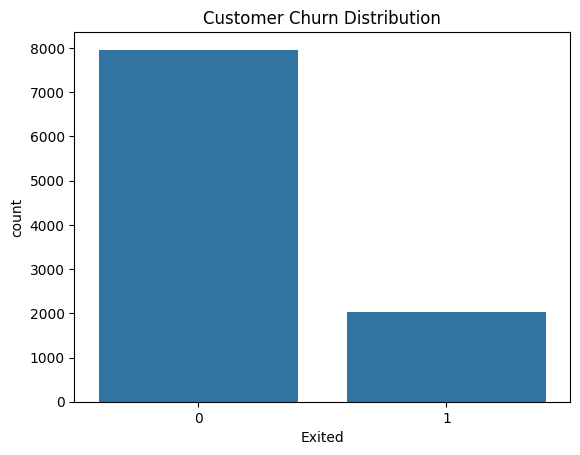

In [10]:
sns.countplot(x="Exited", data=df)
plt.title("Customer Churn Distribution")
plt.show()

In [11]:
df.drop(["RowNumber","CustomerId","Surname"],axis=1,inplace=True)
df.head()

,CreditScore,Geography,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited
0,619,France,Female,42,2,0.00,1,1,1,101348.88,1
1,608,Spain,Female,41,1,83807.86,1,0,1,112542.58,0
2,502,France,Female,42,8,159660.80,3,1,0,113931.57,1
3,699,France,Female,39,1,0.00,2,0,0,93826.63,0
4,850,Spain,Female,43,2,125510.82,1,1,1,79084.10,0


Gender vs churn

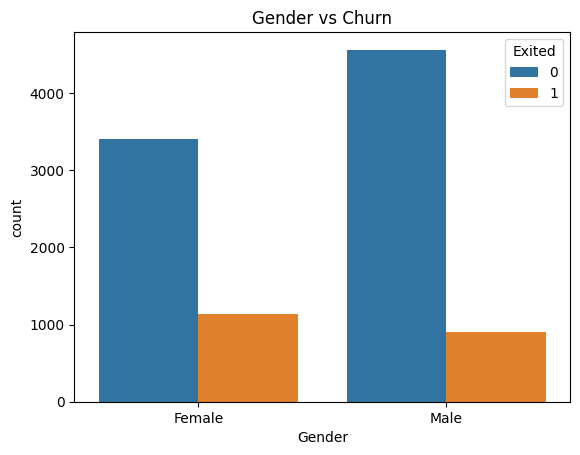

In [12]:
sns.countplot(x="Gender",hue="Exited",data=df)

plt.title("Gender vs Churn")

plt.show()

Geography vs Churn

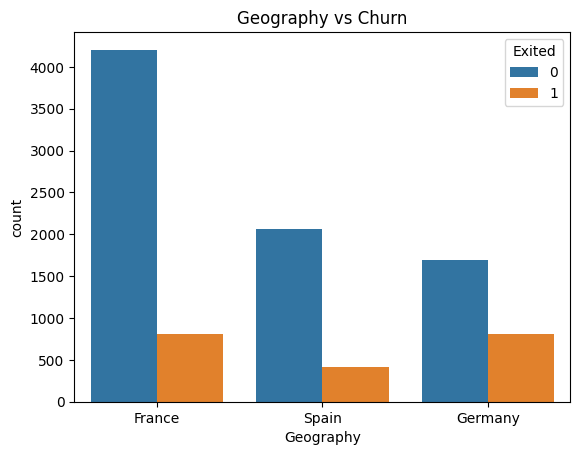

In [13]:
sns.countplot(x="Geography",hue="Exited",data=df)
plt.title("Geography vs Churn")
plt.show()

Age Distribution

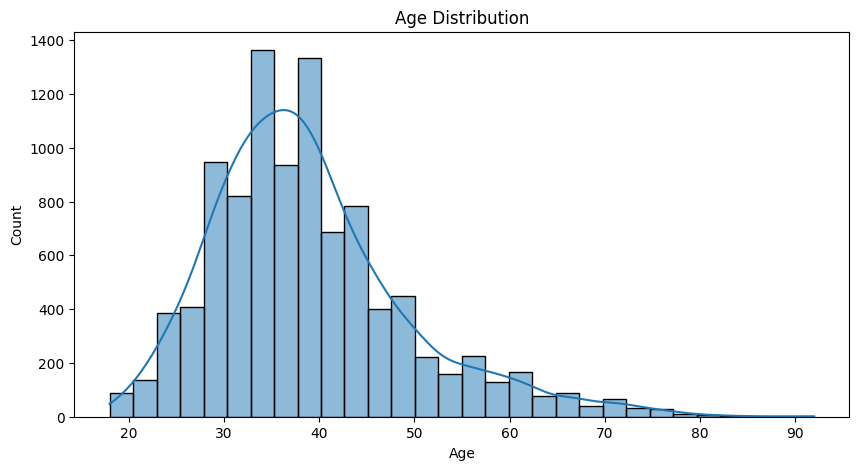

In [14]:
plt.figure(figsize=(10,5))
sns.histplot(df["Age"],bins=30,kde=True)
plt.title("Age Distribution")
plt.show()

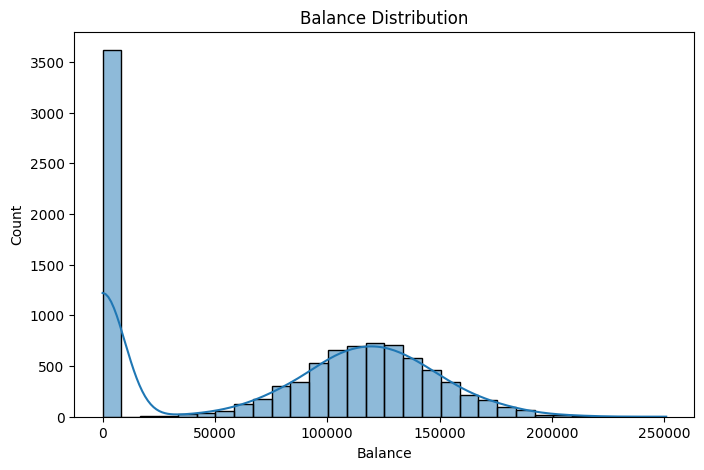

In [15]:
plt.figure(figsize=(8,5))
sns.histplot(df["Balance"],bins=30,kde=True)
plt.title("Balance Distribution")
plt.show()

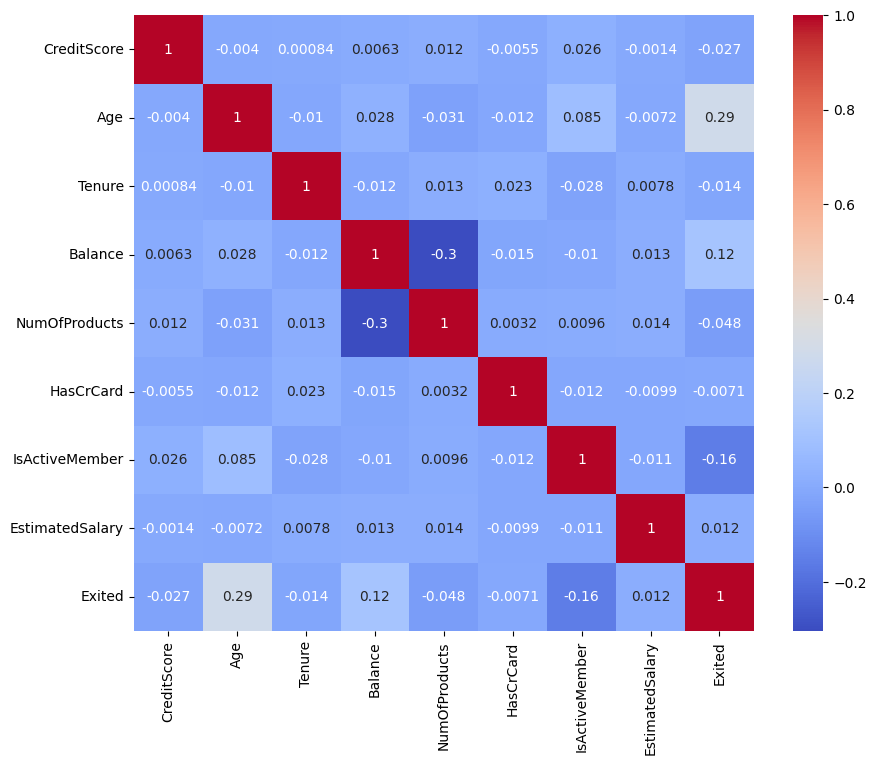

In [16]:
plt.figure(figsize=(10,8))

sns.heatmap(df.select_dtypes(include=np.number).corr(),
            annot=True,
            cmap="coolwarm")
plt.show()

In [17]:
encoder = LabelEncoder()

df["Gender"] = encoder.fit_transform(df["Gender"])

df = pd.get_dummies(df,
                    columns=["Geography"],
                    drop_first=True)

df.head()

,CreditScore,Gender,Age,Tenure,Balance,NumOfProducts,HasCrCard,IsActiveMember,EstimatedSalary,Exited,Geography_Germany,Geography_Spain
0,619,0,42,2,0.00,1,1,1,101348.88,1,False,False
1,608,0,41,1,83807.86,1,0,1,112542.58,0,False,True
2,502,0,42,8,159660.80,3,1,0,113931.57,1,False,False
3,699,0,39,1,0.00,2,0,0,93826.63,0,False,False
4,850,0,43,2,125510.82,1,1,1,79084.10,0,False,True


In [18]:
a = df.drop("Exited",axis=1)

d = df["Exited"]

In [19]:
a_train,a_test,d_train,d_test = train_test_split(
    a,d,
    test_size=0.2,
    random_state=42
)

Logistic Regression

In [20]:
lr = LogisticRegression(max_iter=10000)

lr.fit(a_train,d_train)

pred_lr = lr.predict(a_test)

In [21]:
accuracy = accuracy_score(d_test, pred_lr) * 100
print(f"LOgistic Regression: {accuracy:.2f}%")

LOgistic Regression: 81.15%


Gradient Boosting

In [22]:
gb = GradientBoostingClassifier(random_state=42)

gb.fit(a_train,d_train)

pred_gb = gb.predict(a_test)

In [23]:
accuracy = accuracy_score(d_test, pred_gb) * 100

print(f"Gradient Boosting Accuracy: {accuracy:.2f}%")

Gradient Boosting Accuracy: 86.75%


Random Forest Tree

In [24]:
rf = RandomForestClassifier(
    n_estimators=100,
    random_state=42
)

rf.fit(a_train,d_train)

pred_rf = rf.predict(a_test)

In [25]:
accuracy = accuracy_score(d_test, pred_rf) * 100
print(f"Random Forest Accuracy: {accuracy:.2f}%")

Random Forest Accuracy: 86.60%


Comparision

In [26]:
accuracy = pd.DataFrame({

    "Model":[
        "Logistic Regression",
        "Gradient Boosting",
        "Random Forest"
    ],

    "Accuracy":[
        accuracy_score(d_test,pred_lr),
        accuracy_score(d_test,pred_gb),
        accuracy_score(d_test,pred_rf)
    ]

})

print(accuracy*100)

                                               Model  Accuracy
0  Logistic RegressionLogistic RegressionLogistic...     81.15
1  Gradient BoostingGradient BoostingGradient Boo...     86.75
2  Random ForestRandom ForestRandom ForestRandom ...     86.60


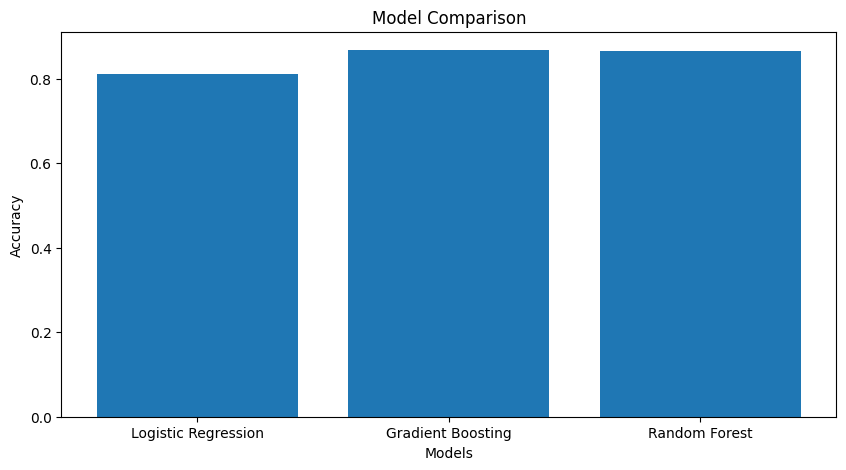

In [27]:
plt.figure(figsize=(10,5))

plt.bar(
    accuracy["Model"],
    accuracy["Accuracy"]
)

plt.xlabel("Models")

plt.ylabel("Accuracy")

plt.title("Model Comparison")

plt.show()

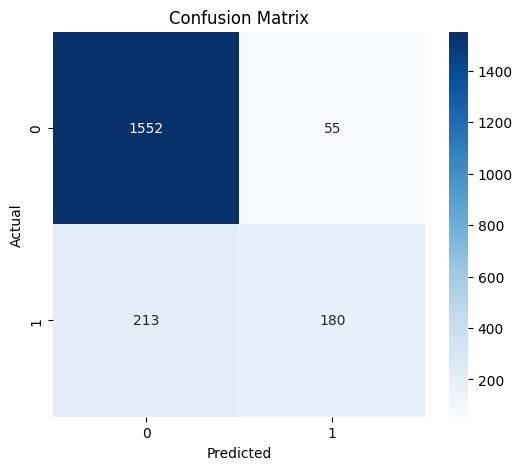

In [28]:
cm = confusion_matrix(d_test,pred_rf)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt="d",
            cmap="Blues")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()

In [29]:
print(classification_report(d_test,pred_rf))

              precision    recall  f1-score   support

           0       0.88      0.97      0.92      1607
           1       0.77      0.46      0.57       393

    accuracy                           0.87      2000
   macro avg       0.82      0.71      0.75      2000
weighted avg       0.86      0.87      0.85      2000



In [30]:
importance = pd.DataFrame({
    "Feature":a.columns,
    "Importance":rf.feature_importances_

})
importance = importance.sort_values(
    by="Importance",
    ascending=False
)
print(importance)

              Feature  Importance
2                 Age    0.239783
8     EstimatedSalary    0.146638
0         CreditScore    0.144214
4             Balance    0.138613
5       NumOfProducts    0.130255
3              Tenure    0.082427
7      IsActiveMember    0.041110
9   Geography_Germany    0.025711
1              Gender    0.019258
6           HasCrCard    0.018722
10    Geography_Spain    0.013268


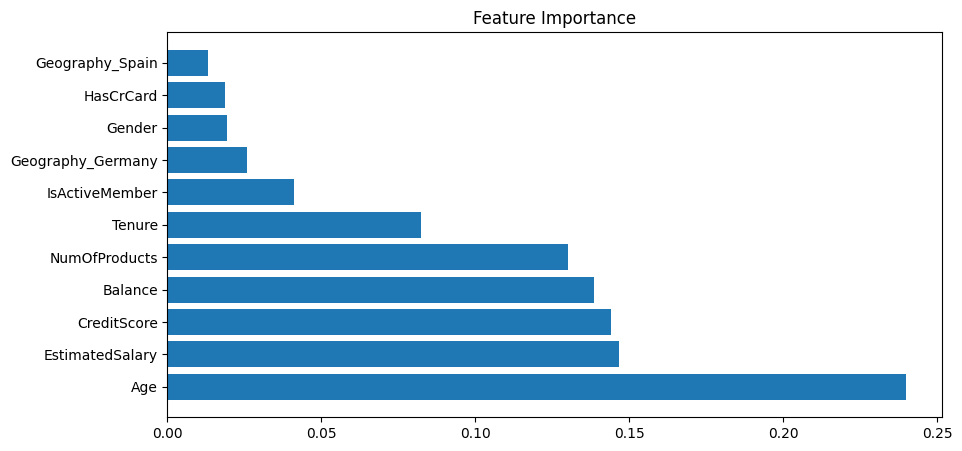

In [31]:
plt.figure(figsize=(10,5))
plt.barh(
    importance["Feature"],
    importance["Importance"]
)
plt.title("Feature Importance")

plt.show()

Conclusion

In [33]:
best_model = accuracy.loc[accuracy["Accuracy"].idxmax()]

print("Best Model:")
print(best_model)

Best Model:
Model       Gradient Boosting
Accuracy               0.8675
Name: 1, dtype: object


In [32]:
index = int(input("Enter Customer Index (0-9999): "))

sample = a.iloc[[index]]
actual = d.iloc[index]

prediction = rf.predict(sample)

print("           CUSTOMER CHURN PREDICTION")

print(f"\nCustomer Index: {index}")

print("\nCustomer Details:")
print(sample)

print("\nActual Status     :",
      "Churn" if actual == 1
      else "Stay")
print("Predicted Status  :",
      "Churn" if prediction[0] == 1
      else "Stay")

if actual == prediction[0]:
    print("\n Prediction is Correct")
else:
    print("\n Prediction is Incorrect")


Enter Customer Index (0-9999): 5
           CUSTOMER CHURN PREDICTION

Customer Index: 5

Customer Details:
   CreditScore  Gender  Age  Tenure    Balance  NumOfProducts  HasCrCard  \
5          645       1   44       8  113755.78              2          1   

   IsActiveMember  EstimatedSalary  Geography_Germany  Geography_Spain  
5               0        149756.71              False             True  

Actual Status     : Churn
Predicted Status  : Churn

 Prediction is Correct
